<a href="https://colab.research.google.com/github/vision1011/Artificial-Intelligence-and-Machine-Learning/blob/main/visionTask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import requests
import zipfile
from tqdm import tqdm

# URL for the 90MB RGB dataset
url = "https://madm.dfki.de/files/sentinel/EuroSAT.zip"
file_name = "eurosat.zip"
extract_path = "/content/EuroSAT_RGB"

# 1. Download bypassing SSL
print("Downloading RGB Dataset (approx. 90MB)...")
response = requests.get(url, verify=False, stream=True)
total_size = int(response.headers.get('content-length', 0))

with open(file_name, "wb") as f, tqdm(
    desc=file_name,
    total=total_size,
    unit='iB',
    unit_scale=True,
    unit_divisor=1024,
) as bar:
    for data in response.iter_content(chunk_size=1024):
        size = f.write(data)
        bar.update(size)

# 2. Extract
print("\nExtracting files...")
with zipfile.ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# 3. Set the correct path
data_dir = "/content/EuroSAT_RGB/2750"

print("\n--- DONE! ---")
print("Folders found in local storage:")
for folder in sorted(os.listdir(data_dir)):
    folder_path = os.path.join(data_dir, folder)
    if os.path.isdir(folder_path):
        print(f" - {folder}: {len(os.listdir(folder_path))} images")

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'madm.dfki.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
eurosat.zip: 100%|██████████| 89.9M/89.9M [00:05<00:00, 17.6MiB/s]



Extracting files...

--- DONE! ---
Folders found in local storage:
 - AnnualCrop: 3000 images
 - Forest: 3000 images
 - HerbaceousVegetation: 3000 images
 - Highway: 2500 images
 - Industrial: 2500 images
 - Pasture: 2000 images
 - PermanentCrop: 2500 images
 - Residential: 3000 images
 - River: 2500 images
 - SeaLake: 3000 images


In [ ]:
import tensorflow as tf

# The local path where we just successfully downloaded the data
DATA_DIR = "/content/EuroSAT_RGB/2750"
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

# Load the training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical' # Important: Must match 'categorical_crossentropy'
)

# Load the validation data
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Optimization for speed
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("Datasets defined successfully!")

Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.
Datasets defined successfully!


In [ ]:
from tensorflow.keras import layers, models

model_baseline = models.Sequential([
    # Use 'shape' instead of 'input_shape' to avoid the warning
    layers.Input(shape=(64, 64, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_baseline.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

print("Training Baseline Model...")
history_baseline = model_baseline.fit(train_ds, validation_data=val_ds, epochs=10)

Training Baseline Model...
Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 134s 195ms/step - accuracy: 0.3825 - loss: 2.5005 - val_accuracy: 0.3904 - val_loss: 1.5580
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 131s 180ms/step - accuracy: 0.5218 - loss: 1.3351 - val_accuracy: 0.5196 - val_loss: 1.2506
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 123s 182ms/step - accuracy: 0.6080 - loss: 1.0977 - val_accuracy: 0.5378 - val_loss: 1.2306
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 122s 181ms/step - accuracy: 0.6712 - loss: 0.9274 - val_accuracy: 0.6124 - val_loss: 1.1097
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 123s 182ms/step - accuracy: 0.7237 - loss: 0.7843 - val_accuracy: 0.6476 - val_loss: 0.9985
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 145s 187ms/step - accuracy: 0.7613 - loss: 0.6832 - val_accuracy: 0.6774 - val_loss: 1.0129
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 123s 183ms/step - accuracy: 0.8008 - loss: 0.5782 - val_accuracy: 0.6702 - val_loss: 1.1557
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 142s 183m

In [ ]:
# Part II: Vision Task - Part A
# Model 2: Deeper CNN with Batch Normalization and Dropout to fix overfitting.

from tensorflow.keras import layers, models

model_deeper = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    # Block 1: Feature Extraction + Normalization
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2: Learning more complex spatial features
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3: Deepening the feature map
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Classification Head: Using Dropout to reduce the gap between Train and Val accuracy
    layers.Flatten(),
    layers.Dropout(0.5), # Randomly disables 50% of neurons to prevent memorization
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_deeper.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

print("Starting Training for Deeper Regularized Model (Model 2)...")
history_deeper = model_deeper.fit(train_ds, validation_data=val_ds, epochs=15)

Starting Training for Deeper Regularized Model (Model 2)...
Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 312s 457ms/step - accuracy: 0.6675 - loss: 1.0189 - val_accuracy: 0.6256 - val_loss: 1.1259
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 319s 454ms/step - accuracy: 0.7794 - loss: 0.6292 - val_accuracy: 0.4111 - val_loss: 3.3241
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 326s 460ms/step - accuracy: 0.8262 - loss: 0.4929 - val_accuracy: 0.4704 - val_loss: 2.6770
Epoch 4/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 303s 449ms/step - accuracy: 0.8505 - loss: 0.4215 - val_accuracy: 0.5533 - val_loss: 1.8199
Epoch 5/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 306s 454ms/step - accuracy: 0.8791 - loss: 0.3441 - val_accuracy: 0.7100 - val_loss: 1.0397
Epoch 6/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 312s 462ms/step - accuracy: 0.8951 - loss: 0.3005 - val_accuracy: 0.7685 - val_loss: 0.7879
Epoch 7/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 307s 455ms/step - accuracy: 0.9141 - loss: 0.2432 - val_accuracy: 0.8298 - val_loss: 0.6138
Epoch 8/15
675/6

In [ ]:
# Part II: Vision Task - Part B
# Transfer Learning using MobileNetV2 pre-trained on ImageNet.

import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Load the pre-trained MobileNetV2 model
# include_top=False removes the final 1000-class layer so we can add our 10-class layer
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(64, 64, 3),
    include_top=False,
    weights='imagenet'
)

# 2. Freeze the base model (We don't want to change the pre-trained weights)
base_model.trainable = False

# 3. Create the Transfer Learning model
model_transfer = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), # Flattens the 2D maps into a single vector
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # Helps generalize to satellite imagery
    layers.Dense(10, activation='softmax') # Our 10 EuroSAT classes
])

model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting Transfer Learning Training (Part B)...")
# We only need 5-10 epochs because the model already knows how to "see" shapes and colors
history_transfer = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

/tmp/ipykernel_12479/3240884445.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting Transfer Learning Training (Part B)...
Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 101s 140ms/step - accuracy: 0.6351 - loss: 1.0726 - val_accuracy: 0.6941 - val_loss: 0.8843
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 92s 136ms/step - accuracy: 0.7084 - loss: 0.8266 - val_accuracy: 0.7024 - val_loss: 0.8657
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 141s 134ms/step - accuracy: 0.7367 - loss: 0.7410 - val_accuracy: 0.7046 - val_loss: 0.8754
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 91s 135ms/step - accuracy: 0.7594 - loss: 0.6713 - val_accuracy: 0.7069 - val_loss: 0.9096
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 142s 135ms/step - accuracy: 0.7840 - loss: 0.6133 - val_accuracy: 0.7087 - val_loss: 0.9406
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 142s 134ms/step - accuracy: 0.7927 - loss: 0.5697 - val_accuracy: 0.7061 - val_loss: 0.9946
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 142s 135ms/step - accuracy: 0.8109 - loss: 0.5224 - val_accuracy: 0.7007 

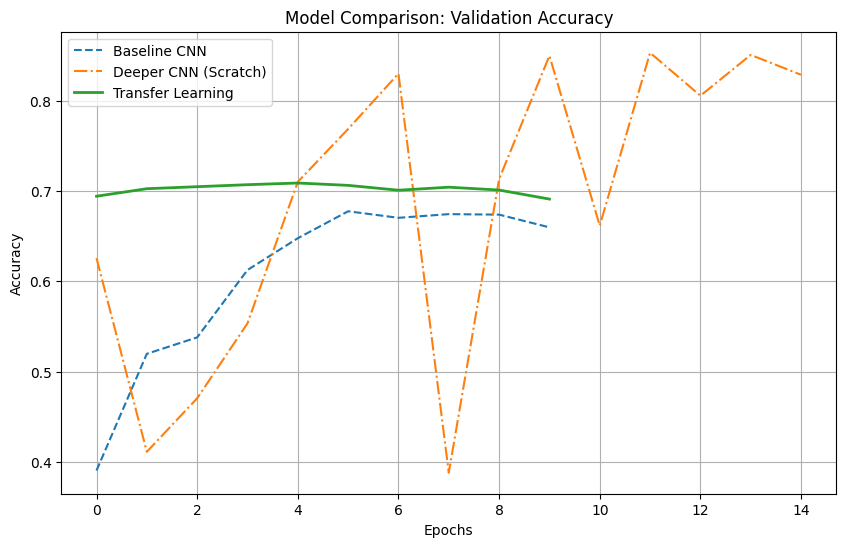


--- Final Classification Report (Deeper CNN) ---
                      precision    recall  f1-score   support

          AnnualCrop       0.92      0.68      0.78       559
              Forest       0.80      1.00      0.89       614
HerbaceousVegetation       0.78      0.73      0.75       589
             Highway       0.79      0.78      0.78       499
          Industrial       0.97      0.91      0.94       488
             Pasture       0.90      0.81      0.86       393
       PermanentCrop       0.55      0.91      0.68       529
         Residential       0.96      0.77      0.85       637
               River       0.93      0.75      0.83       491
             SeaLake       0.97      0.94      0.96       601

            accuracy                           0.83      5400
           macro avg       0.86      0.83      0.83      5400
        weighted avg       0.86      0.83      0.83      5400



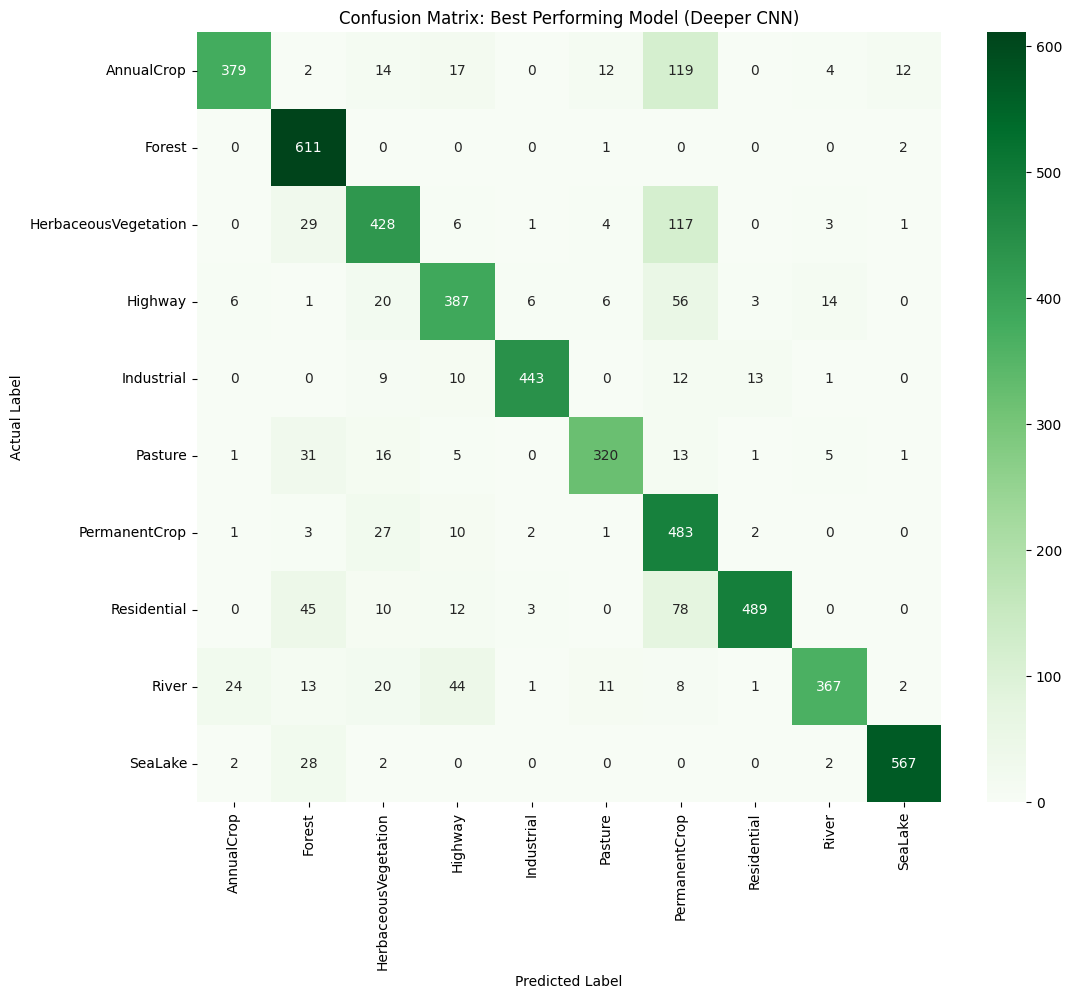

In [ ]:
# Part II: Results & Comparison
# Generate Evaluation Metrics for the Report.

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

# 1. Plot Accuracy Comparison
plt.figure(figsize=(10, 6))
plt.plot(history_baseline.history['val_accuracy'], label='Baseline CNN', linestyle='--')
plt.plot(history_deeper.history['val_accuracy'], label='Deeper CNN (Scratch)', linestyle='-.')
plt.plot(history_transfer.history['val_accuracy'], label='Transfer Learning', linewidth=2)
plt.title('Model Comparison: Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 2. Detailed Evaluation for the Deeper CNN (Your Best Performing Model)
print("\n--- Final Classification Report (Deeper CNN) ---")
y_true = []
y_pred = []

# Using the deeper model since it had the highest val_accuracy (85%)
for x, y in val_ds:
    preds = model_deeper.predict(x, verbose=0)
    y_true.extend(np.argmax(y, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

# 3. Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Best Performing Model (Deeper CNN)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()